<a href="https://colab.research.google.com/github/owen-simon/IS-6482-data-mining/blob/main/Week%207/A4_Simon_Owen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4 - Linear Regression

**Created:** 2026-03-23

**Author:** Owen Simon

---

## Task 1 - Load packages, read the dataset

### Task 1a

In [36]:
# Load Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

# For train-test split
from sklearn.model_selection import train_test_split
# So that we can apply different transformations to different columns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
# For plain linear regression with p-values
import statsmodels.api as sm
# Ridge for ridge regression, Lasso for Lasso regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
# For cross validation later
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate, KFold

RANDOM_STATE = 42

### Task 1b

In [37]:
# Load Data
drive.mount('/content/drive')
NA_sales = pd.read_csv('/content/drive/MyDrive/Data/NA_sales_filtered.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
NA_sales.head()

,Name,Platform,Genre,Rating,Critic_Score,Critic_Count,User_Score,User_Count,NA_Sales
0,Final Fantasy VII,PS,Role-Playing,T,92,20,91,1282,3.01
1,Final Fantasy X,PS2,Role-Playing,T,92,53,86,1056,2.91
2,The Sims 3,PC,Simulation,T,86,75,75,886,0.99
3,Final Fantasy VIII,PS,Role-Playing,T,90,24,85,644,2.28
4,Tekken 3,PS,Fighting,T,96,15,90,367,3.27


In [39]:
NA_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6345 entries, 0 to 6344
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          6345 non-null   object 
 1   Platform      6345 non-null   object 
 2   Genre         6345 non-null   object 
 3   Rating        6345 non-null   object 
 4   Critic_Score  6345 non-null   int64  
 5   Critic_Count  6345 non-null   int64  
 6   User_Score    6345 non-null   int64  
 7   User_Count    6345 non-null   int64  
 8   NA_Sales      6345 non-null   float64
dtypes: float64(1), int64(4), object(4)
memory usage: 446.3+ KB


In [40]:
NA_sales.shape

(6345, 9)

## Task 2 - Data Exploration

## Task 2a

In [41]:
cols = ["Platform", "Genre", "Rating"]

for col in cols:
    vc = NA_sales[col].value_counts()

    print(f"{col}")
    print("Number of different values:", NA_sales[col].nunique())
    print("Most common value:", vc.idxmax())
    print()

Platform
Number of different values: 16
Most common value: PS2

Genre
Number of different values: 12
Most common value: Action

Rating
Number of different values: 5
Most common value: T



### Task 2b

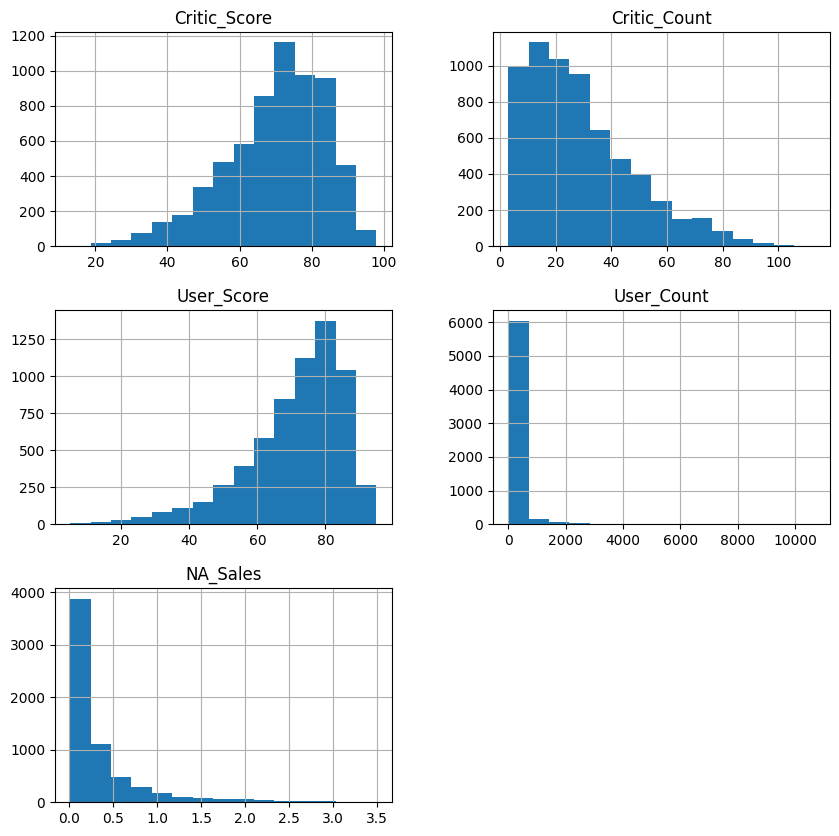

In [42]:
# Use the hist() function from pandas.DataFrame to plot the histogram of the numeric columns with 15 bins
NA_sales.hist(bins=15, figsize=(10, 10))
plt.show()

### Task 2c

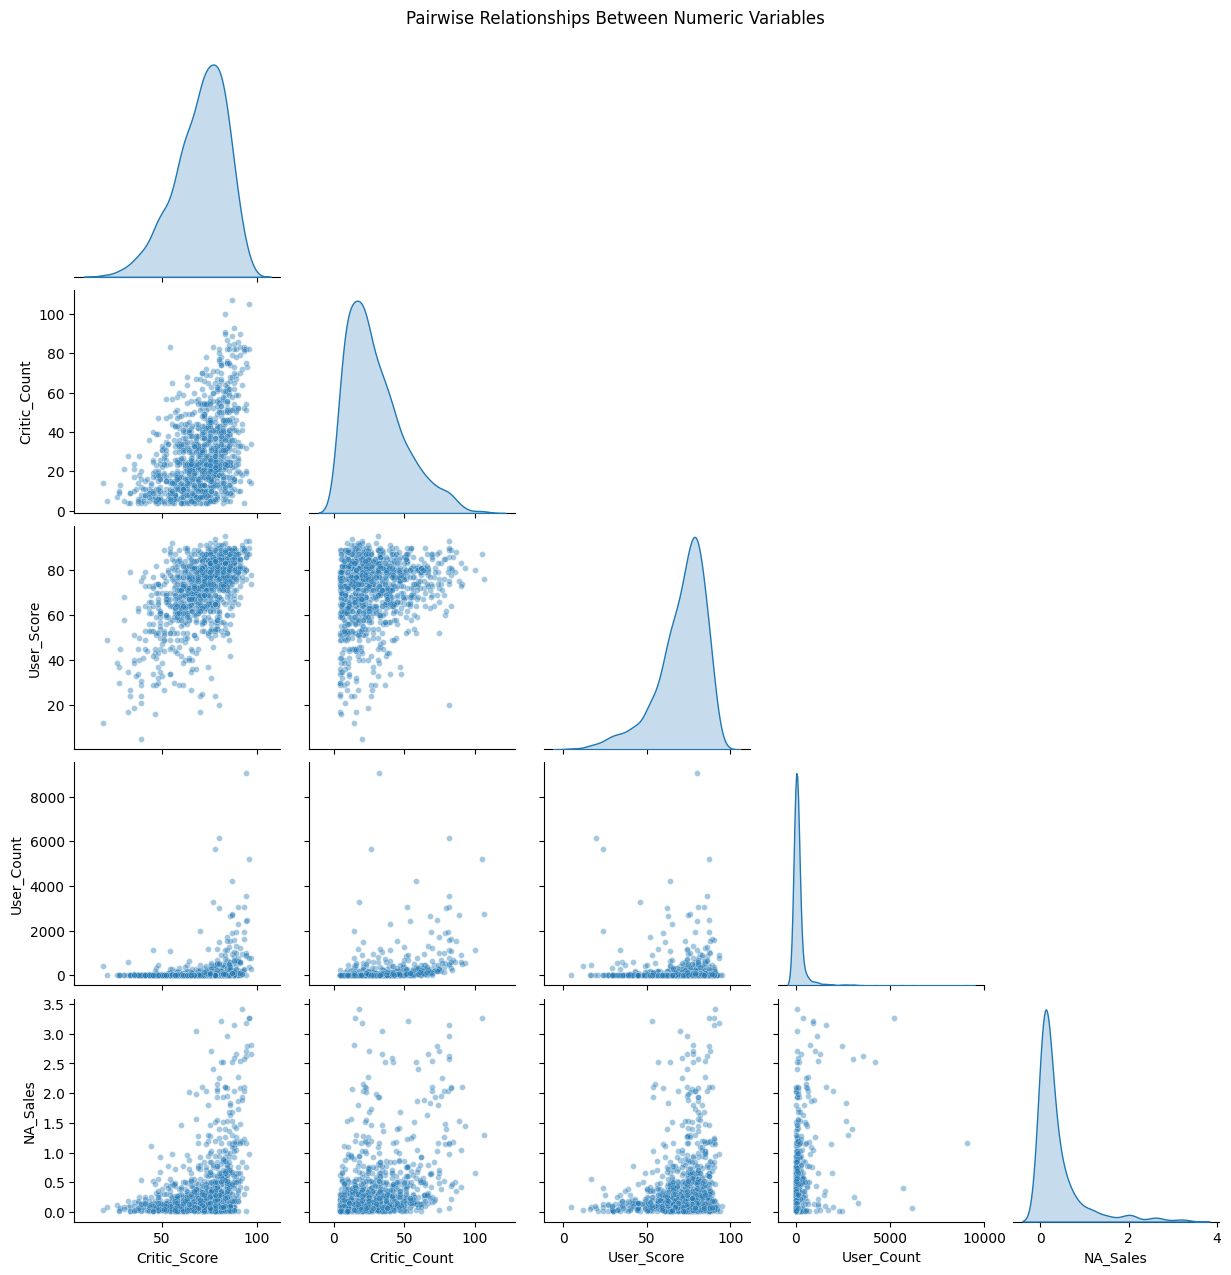

In [43]:
# Sample 1000 rows only for the pairplot
sampled_df = NA_sales.sample(1000, random_state=42)

# Select numeric columns
sampled_df_numeric = sampled_df.select_dtypes(include="number").columns

# Pairplot
g = sns.pairplot(
    data=sampled_df,
    vars=sampled_df_numeric,
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.4, "s": 18}
)

g.fig.suptitle("Pairwise Relationships Between Numeric Variables", y=1.02)
plt.show()